# Generate features using alternative (classical) methods

1. **Readability/accessibility** - SMOG, Flesch-Kincaid, ... 
2. **Grammar** - hunspel spell checker

In [1]:
import readability
import syntok.segmenter as segmenter
from scipy.stats import spearmanr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import shutup
shutup.please()

In [2]:
# import nltk
# nltk.download('punkt_tab')

In [3]:
df_m17 = pd.read_csv('../../data/outputs/m17+/m17_final.csv')

In [4]:
df_m17['abstract_tokenized'] = df_m17['abstract'].apply(lambda text: '\n\n'.join(
    '\n'.join(' '.join(token.value for token in sentence)
              for sentence in paragraph)
    for paragraph in segmenter.analyze(text)))

### Readability 

Used measures: Flesch-Kincaid grade level, Simple Measure of Gobbledgook (SMOG), Automated Readability Index (ARI)

All are interpreted as US-grades, i.e. index of 5 indicitaes that kindergarten-level education is required to read the text while 15 indicates university-level education 

In [5]:
df_m17_measures = df_m17['abstract_tokenized'].apply(lambda x: readability.getmeasures(x, lang='en'))

In [6]:
kincaid = []
ari = []
smog = []
for row in df_m17_measures:
    kincaid.append(row['readability grades']['Kincaid'])
    ari.append(row['readability grades']['ARI'])
    smog.append(row['readability grades']['SMOGIndex'])
df_m17['Kincaid'] = kincaid
df_m17['ARI'] = ari
df_m17['SMOGIndex'] = smog

In [7]:
df_m17[['accessibility','Kincaid', 'ARI', 'SMOGIndex']]

,accessibility,Kincaid,ARI,SMOGIndex
0,medium,15.071817,18.053004,16.662601
1,medium,15.689136,18.109889,18.491933
2,medium,16.444371,17.139563,17.342743
3,medium,15.556745,17.350022,17.662878
4,medium,18.309500,21.475320,18.491933
...,...,...,...,...
1995,medium,16.692940,21.273614,18.297059
1996,medium,18.966702,24.268780,20.320508
1997,medium,12.283429,12.135957,14.338934
1998,medium,22.003226,25.368710,20.320508


In [8]:
accessibility_mapping = {'low': 0, 'medium': 1, 'high': 2}
df_m17['accessibility_numeric'] = df_m17['accessibility'].map(accessibility_mapping)

### Spearman's rank correlation for SMOGIndex vs accessibility (LLM), and accessibility vs target

In [9]:
correlation, p_value = spearmanr(list(df_m17['SMOGIndex']), list(df_m17['accessibility_numeric']))
print(f"Spearman's rank correlation for LLM-generated accessibility and SMOGIndex: {correlation}")
print(f"P-value: {p_value}")

Spearman's rank correlation for LLM-generated accessibility and SMOGIndex: 0.11159033092294962
P-value: 5.64496980251885e-07


Spearman correlation: 0.11159033092294962, p-value: 5.64496980251885e-07


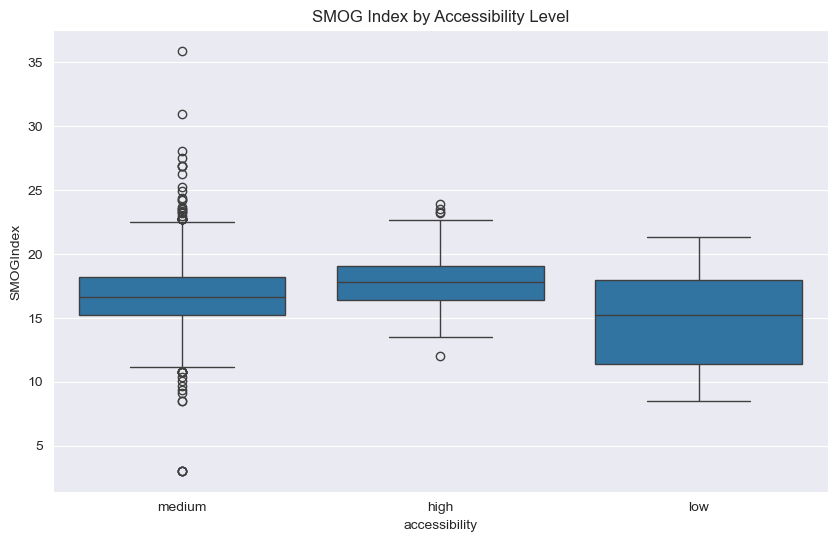

                    mean     median       std
accessibility                                
high           17.792810  17.791405  2.142458
low            15.171089  15.229701  4.177020
medium         16.736056  16.601471  2.554879
ANOVA F-statistic: 11.695554051167576, p-value: 8.916665303301907e-06


In [10]:
from scipy.stats import spearmanr

corr_spearman, p_value = spearmanr(df_m17['SMOGIndex'], df_m17['accessibility_numeric'])
print(f"Spearman correlation: {corr_spearman}, p-value: {p_value}")

plt.figure(figsize=(10, 6))
sns.boxplot(x='accessibility', y='SMOGIndex', data=df_m17)
plt.title('SMOG Index by Accessibility Level')
plt.show()

grouped_stats = df_m17.groupby('accessibility')['SMOGIndex'].agg(['mean', 'median', 'std'])
print(grouped_stats)

from scipy.stats import f_oneway

groups = [df_m17[df_m17['accessibility'] == level]['SMOGIndex'] for level in ['low', 'medium', 'high']]
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat}, p-value: {p_value}")

In [11]:
print("Dataset M17+:")
correlation, p_value = spearmanr(list(df_m17['evaluation']), list(df_m17['SMOGIndex']))
print(f"Spearman's rank correlation for non-LLM-generated readability: {correlation}")
print(f"P-value: {p_value}")

correlation, p_value = spearmanr(list(df_m17['evaluation']), list(df_m17['accessibility_numeric']))
print(f"Spearman's rank correlation for LLM-generated accessibility: {correlation}")
print(f"P-value: {p_value}")

Dataset M17+:
Spearman's rank correlation for non-LLM-generated readability: -0.19960150956587933
P-value: 2.0289015970379948e-19
Spearman's rank correlation for LLM-generated accessibility: -0.06645003776411856
P-value: 0.002947463248060833


In [12]:
def plot_dist(df, columns = ('ARI', 'Kincaid', 'SMOGIndex')):
    plt.figure(figsize=(12, 5))

    for i, col in enumerate(columns, 1):
        plt.subplot(1, 3, i)
    
        sns.histplot(df[col], bins=20, kde=True, color='blue', alpha=0.6)
    
        mean_value = df[col].mean()
        plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_value:.2f}')
    
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.legend()  
    
    plt.tight_layout()
    plt.show()


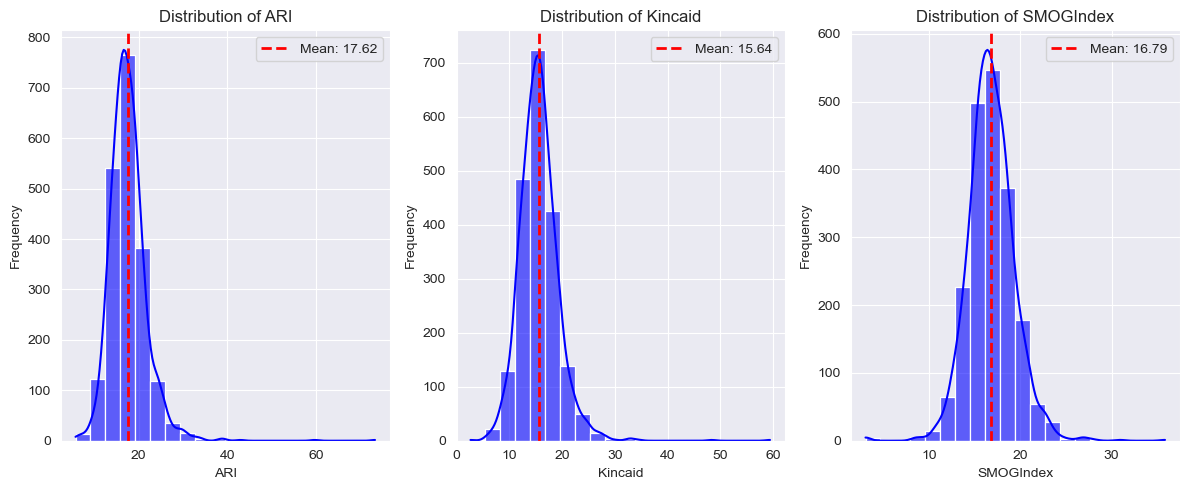

In [13]:
plot_dist(df_m17)

### Grammar

Check grammar using lanugagetool check, with python inplementation done in language_tool_python library.

In [14]:
import language_tool_python

tool = language_tool_python.LanguageTool('en')

def has_grammar_error(text):
    matches = tool.check(text)

    return 1 if matches else 0  

df_m17['grammar_ltp'] = df_m17['abstract'].apply(has_grammar_error)

In [15]:
print(df_m17[['abstract', 'grammar_ltp', 'grammar']].head())

                                            abstract  grammar_ltp  grammar
0  This text depicts the mechanisms that created ...            0        0
1  Translational control targeting the initiation...            0        0
2  Layered elemental materials, such as black pho...            0        1
3  The aim of this book is to unlock the power of...            0        0
4  Theory predicts that higher biodiversity in th...            0        0


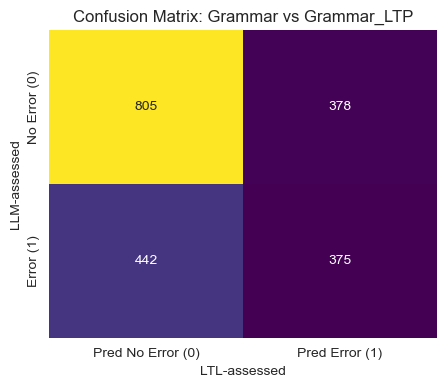

In [16]:
cm = confusion_matrix(df_m17['grammar'], df_m17['grammar_ltp'])
cm_df = pd.DataFrame(cm, index=["No Error (0)", "Error (1)"], columns=["Pred No Error (0)", "Pred Error (1)"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.title("Confusion Matrix: Grammar vs Grammar_LTP")
plt.ylabel("LLM-assessed")
plt.xlabel("LTL-assessed")
plt.show()


### Spearman's rank correlation for grammar_ltp vs grammar (LLM), and grammar_ltp vs target

In [17]:
correlation, p_value = spearmanr(list(df_m17['grammar']), list(df_m17['grammar_ltp']))
print(f"Spearman's rank correlation for LLM-generated grammar and LTP-generated grammar: {correlation}")
print(f"P-value: {p_value}")

Spearman's rank correlation for LLM-generated grammar and LTP-generated grammar: 0.14149873425630757
P-value: 2.0698898580670828e-10


In [18]:
print("Dataset M17+:")
correlation, p_value = spearmanr(list(df_m17['evaluation']), list(df_m17['grammar_ltp']))
print(f"Spearman's rank correlation for non-LLM-generated grammar and evaluation: {correlation}")
print(f"P-value: {p_value}")

correlation, p_value = spearmanr(list(df_m17['evaluation']), list(df_m17['grammar']))
print(f"Spearman's rank correlation for LLM-generated grammar and evaluation: {correlation}")
print(f"P-value: {p_value}")

Dataset M17+:
Spearman's rank correlation for non-LLM-generated grammar and evaluation: -0.004378300218901396
P-value: 0.8448590240758131
Spearman's rank correlation for LLM-generated grammar and evaluation: 0.21793361864537578
P-value: 6.271644675447013e-23
